## **Session 7** - K-Nearest Neighborhood (KNN)
این الگوریتم داده جدید را بر اساس نزدیک ترین همسایه های آن دسته بندی می کند
این الگوریتم فرض می‌کند که چیزهای مشابه در مجاورت هم وجود دارند، که به عنوان «اصل شباهت» شناخته می‌شود.

- **Non-parametric:** KNN doesn't make assumptions about the underlying data distribution.
- **Instance-based:** Also known as lazy learning, KNN doesn't create a generalized model during training but uses the entire training dataset for making predictions.

![](images/img_15.png)

The 'K' in KNN represents the number of nearest neighbors the algorithm considers when making a prediction.



###  The KNN Algorithm: How It Works
The KNN algorithm follows these main steps:

1. **Load the data:** Prepare your training dataset with features and corresponding labels.
2. **Choose K:** Select the number of nearest neigh##bors to consider.
3. **Calculate distances:** For a new data point, calculate its distance to all points in the training set.
4. **Find nearest neighbors:** Identify the K training points closest to the new data point.
5. **Vote:** Assign the class label based on the majority class among the K nearest neighbors.

---

#### Calculating Distances
For two points $p = (p_1, p_2, ..., p_n)$ and $q = (q_1, q_2, ..., q_n)$ in n-dimensional space, the Euclidean distance is given by:
$$d(p,q) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$$

**Note:** Feature scaling is often necessary before applying KNN to ensure that all features contribute equally to the distance calculation.

---

#### Finding Nearest Neighbors
Once distances are calculated, the algorithm identifies the K training samples closest to the new data point. This is typically done by sorting the distances in ascending order and selecting the top K.

In [1]:
import numpy as np

def find_nearest_neighbors(X_train, y_train, x_new, K):
    distances = np.sqrt(np.sum((X_train - x_new)**2, axis=1))
    nearest_neighbor_ids = distances.argsort()[:K]
    return y_train[nearest_neighbor_ids]

---

#### Majority Voting
After identifying the K nearest neighbors, KNN assigns the class label based on the majority class among these neighbors. In case of a tie, it's common to choose the class of the nearest neighbor.


In [ ]:
from scipy.stats import mode

def knn_predict(X_train, y_train, x_new, K):
    neighbors = find_nearest_neighbors(X_train, y_train, x_new, K)
    return mode(neighbors)[0][0]

---

#### KNN Decision Boundaries
The decision boundaries in KNN are implicitly defined by the training data and can be quite complex. As K increases, the decision boundary generally becomes smoother.



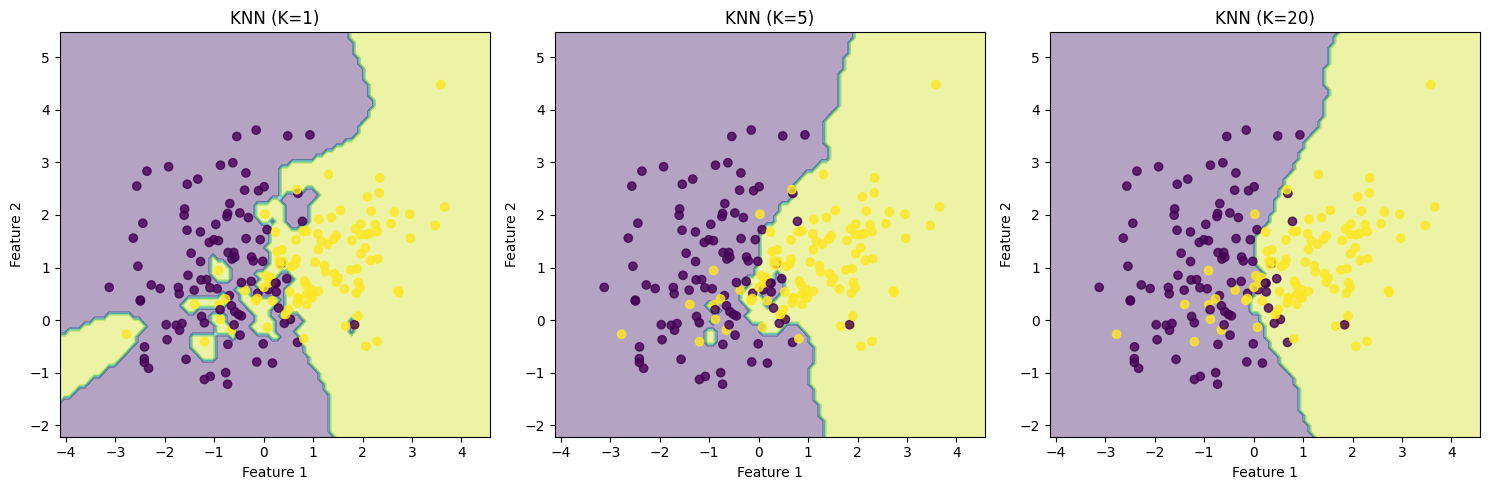

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification

# Generate synthetic dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42,
)

# Plot decision boundaries for different K values
plt.figure(figsize=(15, 5))
for i, k in enumerate([1, 5, 20]):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)

    # Plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)
    plt.title(f"KNN (K={k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Distance Metrics in KNN
 **Concept:** The distance metric defines how "closeness" is measured between data points in the feature space.

![](images/img_16.png)

---

#### Euclidean Distance
فاصله اقلیدسی متداول ترین نوع محاسبه فاصله است که اغلب برای داده های گسسته کاربردی است

$d_{Euclidean}(p,q) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$

```python
import numpy as np

def euclidean_distance(p, q):
    return np.sqrt(np.sum((p - q)**2))
```

---

#### Manhattan Distance

$d_{Manhattan}(p,q) = \sum_{i=1}^n |p_i - q_i|$

```python
def manhattan_distance(p, q):
    return np.sum(np.abs(p - q))
```

---

#### Cosine Similarity
$similarity_{Cosine}(p,q) = \frac{p \cdot q}{||p|| ||q||} = \frac{\sum_{i=1}^n p_i q_i}{\sqrt{\sum_{i=1}^n p_i^2} \sqrt{\sum_{i=1}^n q_i^2}}$

To convert cosine similarity to a distance metric, we can use:

$d_{Cosine}(p,q) = 1 - similarity_{Cosine}(p,q)$

---

#### Compare


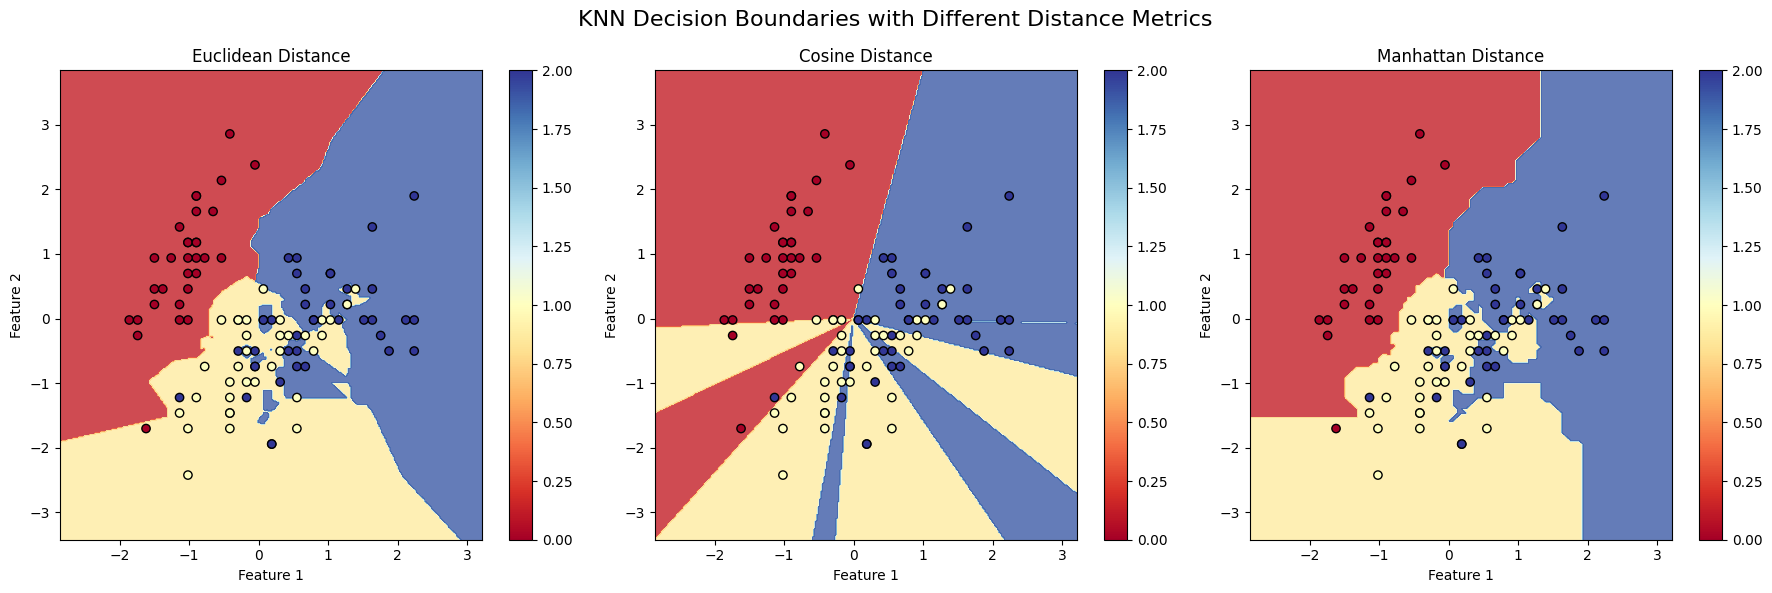

Classification Accuracies:
Euclidean Distance: 0.8444
Cosine Distance: 0.7111
Manhattan Distance: 0.8000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, [0, 1]]  # We'll use only the first two features for visualization
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the distance metrics and their corresponding KNN classifiers
distance_metrics = ['euclidean', 'cosine', 'manhattan']
classifiers = {
    metric: KNeighborsClassifier(n_neighbors=3, metric=metric)
    for metric in distance_metrics
}

# Train the classifiers
for clf in classifiers.values():
    clf.fit(X_train_scaled, y_train)

# Create a mesh grid for plotting decision boundaries
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Plot the decision boundaries and scatter plots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('KNN Decision Boundaries with Different Distance Metrics', fontsize=16)

for ax, (metric, clf) in zip(axs, classifiers.items()):
    # Plot decision boundary
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot scatter points
    scatter = ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolor='black')

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'{metric.capitalize()} Distance')

    # Add a color bar
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

# Print classification accuracies
print("Classification Accuracies:")
for metric, clf in classifiers.items():
    accuracy = clf.score(X_test_scaled, y_test)
    print(f"{metric.capitalize()} Distance: {accuracy:.4f}")

### Choosing the Optimal K Value
انتخاب مقدار $K$ مناسب در این الگوریتم بسیار حیاتی است زیرا عملکرد مدل را تحت تاثیر زیادی قرار می دهد.

البته این طبیعی است. اگر داده جدید را تنها با دو همسایه نزدیک آن مقایسه کنیم نتیجه بسیار متفاوت از حالتی خواهد بود که آن را با ۱۰ همسایه نزدیک مقایسه می کنیم

در واقع اگر مقدار $K$ را کمتر انتخاب کنیم واریانس را افزایش داده ایم و مرز تصمیم‌گیری هموارتری ساخته ایم

اما اگر مقدار $K$ بزرگتری انتخاب کنیم،‌ بایاس $(Bias)$ بیشتری ایجاد می کنیم و داده بیشتر به سمت جزپیات فیت می شود

- **Small K:** Leads to a more flexible model that can capture complex patterns but is sensitive to noise.
- **Large K:** Results in a smoother decision boundary, potentially missing important patterns but more robust to outliers.

---

#### Methods for Selecting K
- **Cross-validation** is one of the most common and effective methods for selecting K. It involves splitting the data into training and validation sets multiple times and evaluating the model's performance for different K values.

- The **elbow method** involves plotting the model's performance against a range of K values and looking for the "elbow point" where the rate of improvement slows significantly.

---

#### Considerations in K Selection
1. **Dataset Size:**
    - For larger datasets, larger K values can be more appropriate as they reduce the impact of noise.
    - For smaller datasets, smaller K values might be necessary to capture patterns effectively.
2. **Dimensionality:**
    - In high-dimensional spaces, the concept of "nearest neighbors" becomes less meaningful due to the curse of dimensionality.
    - Consider dimensionality reduction techniques or using distance metrics that perform well in high dimensions.
3. **Class Imbalance:**
    - In imbalanced datasets, choosing K based solely on accuracy can be misleading.
    - Consider using other metrics like F1-score or balanced accuracy, or techniques like stratified cross-validation.



### Advantages and Disadvantages of KNN

---

#### Advantages

1. Simplicity and Interpretability
2. Non-Parametric Nature
3. Versatility: KNN can be used for both classification and regression tasks, and it's effective for multi-class problems.
4. No Training Phase: KNN is a lazy learning algorithm, meaning it doesn't have a training phase. This can be advantageous when dealing with dynamic datasets.

---

#### Disadvantages
1. Computational Complexity
2. Curse of Dimensionality
3. Sensitivity to imbalance data
4. Sensitive to Noisy Data and **Outliers**
5. need for feature scaling

### Implementing KNN in Python

---

#### Basic KNN Implementation from Scratch


In [4]:
import numpy as np
from collections import Counter

class SimpleKNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))

    def predict(self, X):
        predictions = [self._predict(x) for x in X] # Predict for every sample (row) of data
        return np.array(predictions)

    def _predict(self, x):
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# Example usage
X_train = np.array([[1, 2], [2, 3], [3, 1], [4, 2], [5, 4]])
y_train = np.array([0, 0, 1, 1, 1])

knn = SimpleKNN(k=3)
knn.fit(X_train, y_train)

In [5]:
X_test = np.array([[3, 2], [4.5, 3]])
predictions = knn.predict(X_test)
print("Predictions:", predictions)

Predictions: [1 1]


#### Using Scikit-learn's KNN Implementation


In [6]:
from sklearn.neighbors import KNeighborsClassifier #Import
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


#### Weighted KNN

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Uniform weighting (default)
knn_uniform = KNeighborsClassifier(n_neighbors=5, weights='uniform')

# Distance-based weighting
knn_distance = KNeighborsClassifier(n_neighbors=5, weights='distance')

# Compare performances
models = [knn_uniform, knn_distance]
model_names = ['Uniform Weights', 'Distance Weights']

for name, model in zip(model_names, models):
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.4f}")

Uniform Weights Accuracy: 1.0000
Distance Weights Accuracy: 1.0000
